# Climate Policy Well-being Classification Notebook

## BGE + TF-IDF baseline/final model with SPECTER ablation

This notebook implements the strategy requested:

1. Keep **BGE + TF-IDF** as the main baseline/final model.
2. Add **SPECTER embeddings** as an additional scientific-document representation.
3. Run a clean ablation study under the same Stage 1 and Stage 2 evaluation logic.
4. Produce numerical comparison tables, theme-wise validation reports, and a final annotated master file.

### Experiments included

| Experiment | Purpose |
|---|---|
| `TFIDF_ONLY` | lexical baseline |
| `BGE_ONLY` | semantic embedding only |
| `SPECTER_ONLY` | scientific-paper embedding only |
| `BGE_TFIDF_BASELINE_FINAL` | recommended baseline/final model |
| `SPECTER_TFIDF` | tests whether SPECTER helps with lexical features |
| `BGE_SPECTER_TFIDF` | full hybrid ablation: BGE + SPECTER + TF-IDF |

The final annotation step uses `BGE_TFIDF_BASELINE_FINAL` by default. After checking the ablation table, you may manually switch the final model to `BGE_SPECTER_TFIDF` only if it improves both binary screening and theme macro-F1.


In [1]:
# ============================================================
# 0. Optional dependency setup
# ============================================================
# This cell is intentionally safe: it does NOT uninstall torch.
# If transformers/torch are missing in Kaggle, uncomment the install command below,
# run it once, then restart the kernel.

# import sys, subprocess
# subprocess.check_call([
#     sys.executable, "-m", "pip", "install", "-U", "--no-cache-dir",
#     "transformers", "accelerate", "safetensors"
# ])

try:
    import torch, transformers
    print("torch:", torch.__version__)
    print("transformers:", transformers.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("Optional HF stack check failed:", repr(e))
    print("The notebook can still run TF-IDF-only, but BGE/SPECTER need torch + transformers.")


torch: 2.10.0+cu128
transformers: 5.0.0
CUDA available: True
GPU: Tesla P100-PCIE-16GB


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [3]:
# ============================================================
# 1. Imports and global configuration
# ============================================================
import os, re, json, math, gc, time, random, zipfile, warnings, unicodedata, hashlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp

from scipy.special import expit, softmax
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.isotonic import IsotonicRegression
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---------------------------
# File paths
# ---------------------------
# Update these paths if your Kaggle dataset folder name is different.
TRAIN_FILE_CANDIDATES = [
    Path("/kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Human labelled_DTU.xlsx"),
    Path("/kaggle/input/climate-text-dataset/Human labelled_DTU.xlsx"),
    Path("/kaggle/input/Human labelled_DTU.xlsx"),
    Path("/mnt/data/Human labelled_DTU.xlsx"),
    Path("Human labelled_DTU.xlsx"),
]

MASTER_FILE_CANDIDATES = [
    Path("/kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Master file_10k papers.xlsx"),
    Path("/kaggle/input/climate-text-dataset/Master file_10k papers.xlsx"),
    Path("/kaggle/input/Master file_10k papers.xlsx"),
    Path("/mnt/data/Master file_10k papers.xlsx"),
    Path("Master file_10k papers.xlsx"),
]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError("None of these files exist: " + ", ".join(map(str, paths)))

TRAIN_FILE = first_existing(TRAIN_FILE_CANDIDATES)
MASTER_FILE = first_existing(MASTER_FILE_CANDIDATES)

OUTPUT_DIR = Path("/kaggle/working/bge_tfidf_specter_ablation_outputs") if Path("/kaggle/working").exists() else Path("./bge_tfidf_specter_ablation_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "cache_embeddings"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Experiment switches
# ---------------------------
N_FOLDS = 3                     # use 5 for a slower but more paper-ready result
RUN_SVC = True
RUN_SGD = True
RUN_NB = True

USE_HF_EMBEDDINGS = True
FORCE_CPU_EMBEDDINGS = False    # set True if CUDA creates issues
HF_BATCH_SIZE_GPU = 32
HF_BATCH_SIZE_CPU = 8
HF_MAX_LENGTH = 512

# The recommended final model remains BGE + TF-IDF unless you manually change this.
FINAL_EXPERIMENT_NAME = "BGE_TFIDF_BASELINE_FINAL"
AUTO_SWITCH_TO_BGE_SPECTER_IF_BETTER = False

# Strictly exclude ClimateBERT and DeBERTa families.
BGE_MODEL = "BAAI/bge-small-en-v1.5"
SPECTER_MODEL = "allenai/specter"
EMBEDDING_MODELS_TO_CACHE = [BGE_MODEL, SPECTER_MODEL]

for model_name in EMBEDDING_MODELS_TO_CACHE:
    assert "climatebert" not in model_name.lower()
    assert "deberta" not in model_name.lower()

# Feature and decision settings
WORD_MAX_FEATURES = 80000
CHAR_MAX_FEATURES = 50000
EMBEDDING_WEIGHT = 2.0

# Guardrails to avoid over-acceptance in the master file.
ACCEPT_RATE_LOWER_MULT = 0.55
ACCEPT_RATE_UPPER_MULT = 1.85
ABSOLUTE_ACCEPT_RATE_CAP = 0.22
MIN_ACCEPT_RECALL_FOR_SCREENING = 0.45

ABLATION_EXPERIMENTS = {
    "TFIDF_ONLY": {
        "use_tfidf": True,
        "embedding_models": [],
        "description": "Lexical baseline using word/character TF-IDF only."
    },
    "BGE_ONLY": {
        "use_tfidf": False,
        "embedding_models": [BGE_MODEL],
        "description": "BGE semantic embedding only."
    },
    "SPECTER_ONLY": {
        "use_tfidf": False,
        "embedding_models": [SPECTER_MODEL],
        "description": "SPECTER scientific-document embedding only."
    },
    "BGE_TFIDF_BASELINE_FINAL": {
        "use_tfidf": True,
        "embedding_models": [BGE_MODEL],
        "description": "Recommended baseline/final model: BGE + TF-IDF."
    },
    "SPECTER_TFIDF": {
        "use_tfidf": True,
        "embedding_models": [SPECTER_MODEL],
        "description": "SPECTER + TF-IDF ablation."
    },
    "BGE_SPECTER_TFIDF": {
        "use_tfidf": True,
        "embedding_models": [BGE_MODEL, SPECTER_MODEL],
        "description": "Full hybrid ablation: BGE + SPECTER + TF-IDF."
    },
}

print("Train file:", TRAIN_FILE)
print("Master file:", MASTER_FILE)
print("Output dir:", OUTPUT_DIR)
print("Final experiment:", FINAL_EXPERIMENT_NAME)


Train file: /kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Human labelled_DTU.xlsx
Master file: /kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Master file_10k papers.xlsx
Output dir: /kaggle/working/bge_tfidf_specter_ablation_outputs
Final experiment: BGE_TFIDF_BASELINE_FINAL


In [4]:
# ============================================================
# 2. Data loading and robust column handling
# ============================================================

def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = unicodedata.normalize("NFKC", x)
    x = re.sub(r"\s+", " ", x).strip()
    x = re.sub(r"©\s*\d{4}[^.]*\.?", " ", x)
    x = re.sub(r"All rights reserved\.?", " ", x, flags=re.I)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def find_column(columns, candidates):
    lowered = {c: re.sub(r"[^a-z0-9]+", " ", str(c).lower()).strip() for c in columns}
    for c, low in lowered.items():
        for cand in candidates:
            if cand in low:
                return c
    return None

def decision_to_binary(x):
    s = clean_text(x).lower()
    if s == "":
        return np.nan

    # Reject/exclude must be checked before accept/include because strings can contain both.
    if re.search(r"\b(reject|rejected|exclude|excluded|irrelevant|not relevant|no)\b", s):
        return 0
    if re.search(r"\b(accept|accepted|include|included|relevant|yes)\b", s):
        return 1

    try:
        v = float(s)
        return int(v >= 0.5)
    except Exception:
        return np.nan

def load_training_file(path):
    # Load labelled training file with either real headers or the user's known 10-column format.
    header_df = pd.read_excel(path)
    title_col = find_column(header_df.columns, ["title"])
    abstract_col = find_column(header_df.columns, ["abstract"])
    decision_col = find_column(header_df.columns, ["decision", "accept", "reject", "label", "screening"])
    theme_col = find_column(header_df.columns, ["theme", "category", "code"])

    if title_col is not None and abstract_col is not None and decision_col is not None:
        df = pd.DataFrame()
        df["title"] = header_df[title_col]
        df["abstract"] = header_df[abstract_col]
        df["decision"] = header_df[decision_col]
        df["theme"] = header_df[theme_col] if theme_col is not None else np.nan
        df["_source_row"] = np.arange(len(header_df))
    else:
        raw = pd.read_excel(path, header=None)
        if raw.shape[1] < 10:
            raise ValueError(
                "Training file needs either named columns or at least 10 columns: "
                "source, id, authors, title, year, doi, url, abstract, decision, theme."
            )
        df = raw.iloc[:, :10].copy()
        df.columns = ["source", "paper_id", "authors", "title", "year", "doi", "url", "abstract", "decision", "theme"]
        df["_source_row"] = np.arange(len(df))

    df["title"] = df["title"].apply(clean_text)
    df["abstract"] = df["abstract"].apply(clean_text)
    df["decision"] = df["decision"].apply(clean_text)
    df["theme"] = df["theme"].apply(clean_text).replace("", np.nan)
    df["text"] = (df["title"] + ". " + df["abstract"]).str.strip()
    df["accept_label"] = df["decision"].apply(decision_to_binary)

    before = len(df)
    df = df[df["text"].str.len() > 5].copy()
    df = df[df["accept_label"].notna()].copy()
    df["accept_label"] = df["accept_label"].astype(int)
    df = df.reset_index(drop=True)

    print(f"Training rows loaded: {len(df)} / {before}")
    print("Accept/Reject counts:")
    print(df["accept_label"].value_counts().rename(index={0: "Reject", 1: "Accept"}))
    return df

def load_master_file(path):
    # Load master file and infer title/abstract columns.
    df = pd.read_excel(path)
    title_col = find_column(df.columns, ["title"])
    abstract_col = find_column(df.columns, ["abstract"])

    if title_col is None and df.shape[1] >= 1:
        title_col = df.columns[0]
    if abstract_col is None:
        # Prefer a long text-like column if "abstract" is not explicitly named.
        lengths = {}
        for c in df.columns:
            try:
                lengths[c] = df[c].astype(str).str.len().median()
            except Exception:
                lengths[c] = 0
        abstract_col = max(lengths, key=lengths.get)

    df["_row_id"] = np.arange(len(df))
    df["_title"] = df[title_col].apply(clean_text)
    df["_abstract"] = df[abstract_col].apply(clean_text)
    df["_text"] = (df["_title"] + ". " + df["_abstract"]).str.strip()

    print(f"Master rows loaded: {len(df)}")
    print("Title column:", title_col)
    print("Abstract column:", abstract_col)
    return df

train_df = load_training_file(TRAIN_FILE)
master_df = load_master_file(MASTER_FILE)

accepted_theme_df = train_df[(train_df["accept_label"] == 1) & train_df["theme"].notna()].copy()
if accepted_theme_df.empty:
    raise ValueError("No accepted rows with theme labels were found.")

theme_encoder = LabelEncoder()
theme_encoder.fit(accepted_theme_df["theme"].astype(str))
theme_names = list(theme_encoder.classes_)
theme2id = {theme: i for i, theme in enumerate(theme_names)}
id2theme = {i: theme for theme, i in theme2id.items()}
N_THEMES = len(theme_names)

train_df["theme_id"] = train_df["theme"].map(theme2id)

with open(OUTPUT_DIR / "theme_mapping.json", "w") as f:
    json.dump({"theme2id": theme2id, "id2theme": id2theme}, f, indent=2)

print("\nNumber of themes:", N_THEMES)
print("Theme counts among accepted labelled papers:")
display(train_df.loc[train_df["accept_label"].eq(1), "theme"].value_counts(dropna=False).rename("count").to_frame())


Training rows loaded: 1721 / 1737
Accept/Reject counts:
accept_label
Reject    1522
Accept     199
Name: count, dtype: int64
Master rows loaded: 10176
Title column: Article Title
Abstract column: Abstract

Number of themes: 12
Theme counts among accepted labelled papers:


,count
theme,
Climate change mitigation options & Well-being,84
"Empowering People & Governance, Policy",31
Implemented mitigation Options and Well-being,21
"Well-being, Community & Societal Systems Thinking",11
SDGs and Well-being,10
"Equity, Social Justice, Just Transition",8
Better Well-being Metric,7
Ecosystem & Non-human Well-being,6
Integrated Responses and Well-being,6


In [5]:
# ============================================================
# 3. Frozen BGE and SPECTER embedding extraction
# ============================================================

all_texts = pd.concat([train_df["text"], master_df["_text"]], ignore_index=True).fillna("").tolist()
n_train = len(train_df)
n_master = len(master_df)

def detect_embedding_device():
    if FORCE_CPU_EMBEDDINGS:
        return "cpu"
    try:
        import torch
        if torch.cuda.is_available():
            try:
                _ = torch.arange(4, device="cuda")
                print("CUDA sanity check passed:", torch.cuda.get_device_name(0))
                return "cuda"
            except Exception as e:
                print("CUDA exists but failed sanity check. Falling back to CPU:", repr(e))
    except Exception as e:
        print("Torch/CUDA check failed. Falling back to CPU:", repr(e))
    return "cpu"

def embedding_cache_name(model_name, texts):
    safe = re.sub(r"[^A-Za-z0-9]+", "_", model_name).strip("_")
    sample = "\n".join(texts[:5] + texts[-5:]) + f"\nN={len(texts)}\nMODEL={model_name}\nMAXLEN={HF_MAX_LENGTH}"
    h = hashlib.md5(sample.encode("utf-8", errors="ignore")).hexdigest()[:12]
    return CACHE_DIR / f"{safe}_{h}.npy"

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

def embed_texts_with_hf(model_name, texts):
    if not USE_HF_EMBEDDINGS:
        print(f"Skipping {model_name}: USE_HF_EMBEDDINGS=False")
        return None

    cache_path = embedding_cache_name(model_name, texts)
    if cache_path.exists():
        print(f"Loading cached embeddings for {model_name}: {cache_path.name}")
        return np.load(cache_path)

    try:
        import torch
        from transformers import AutoTokenizer, AutoModel

        device = detect_embedding_device()
        batch_size = HF_BATCH_SIZE_GPU if device == "cuda" else HF_BATCH_SIZE_CPU

        print(f"Loading {model_name} on {device} ...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name)
        model.to(device)
        model.eval()

        vectors = []
        start = time.time()
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch = [clean_text(t) for t in texts[i:i + batch_size]]
                enc = tokenizer(
                    batch,
                    padding=True,
                    truncation=True,
                    max_length=HF_MAX_LENGTH,
                    return_tensors="pt"
                )
                enc = {k: v.to(device) for k, v in enc.items()}
                out = model(**enc)

                if "specter" in model_name.lower():
                    # Original SPECTER representations are usually taken from the CLS token.
                    pooled = out.last_hidden_state[:, 0, :]
                else:
                    # BGE-style sentence/document embedding via mean pooling.
                    pooled = mean_pool(out.last_hidden_state, enc["attention_mask"])

                pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
                vectors.append(pooled.detach().cpu().numpy().astype("float32"))

                if (i // batch_size) % 25 == 0:
                    print(f"  {model_name}: {min(i + batch_size, len(texts))}/{len(texts)}")

        arr = np.vstack(vectors).astype("float32")
        np.save(cache_path, arr)
        print(f"Saved {model_name} embeddings: {arr.shape} | time: {(time.time()-start)/60:.1f} min")

        del model
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()
        return arr

    except Exception as e:
        print(f"Embedding extraction failed for {model_name}: {repr(e)}")
        print("This model will be marked unavailable. Related ablation rows will be skipped.")
        return None

DENSE_ALL_BY_MODEL = {}
DENSE_TRAIN_BY_MODEL = {}
DENSE_MASTER_BY_MODEL = {}

for model_name in EMBEDDING_MODELS_TO_CACHE:
    arr = embed_texts_with_hf(model_name, all_texts)
    if arr is not None:
        DENSE_ALL_BY_MODEL[model_name] = arr
        DENSE_TRAIN_BY_MODEL[model_name] = arr[:n_train]
        DENSE_MASTER_BY_MODEL[model_name] = arr[n_train:]
        print(model_name, "train:", DENSE_TRAIN_BY_MODEL[model_name].shape, "master:", DENSE_MASTER_BY_MODEL[model_name].shape)
    else:
        print(model_name, "is unavailable.")

def get_dense_matrix(model_names, split):
    if not model_names:
        return None

    store = DENSE_TRAIN_BY_MODEL if split == "train" else DENSE_MASTER_BY_MODEL
    missing = [m for m in model_names if m not in store]
    if missing:
        return None

    parts = [store[m] for m in model_names]
    if len(parts) == 1:
        return parts[0]
    return np.hstack(parts).astype("float32")

print("\nAvailable embedding models:", list(DENSE_TRAIN_BY_MODEL.keys()))


CUDA exists but failed sanity check. Falling back to CPU: AcceleratorError("CUDA error: no kernel image is available for execution on the device\nSearch for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.\nCUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.\nFor debugging consider passing CUDA_LAUNCH_BLOCKING=1\nCompile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.\n")
Loading BAAI/bge-small-en-v1.5 on cpu ...


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

  allenai/specter: 8/11897
  allenai/specter: 208/11897
  allenai/specter: 408/11897
  allenai/specter: 608/11897
  allenai/specter: 808/11897
  allenai/specter: 1008/11897
  allenai/specter: 1208/11897
  allenai/specter: 1408/11897
  allenai/specter: 1608/11897
  allenai/specter: 1808/11897
  allenai/specter: 2008/11897
  allenai/specter: 2208/11897
  allenai/specter: 2408/11897
  allenai/specter: 2608/11897
  allenai/specter: 2808/11897
  allenai/specter: 3008/11897
  allenai/specter: 3208/11897
  allenai/specter: 3408/11897
  allenai/specter: 3608/11897
  allenai/specter: 3808/11897
  allenai/specter: 4008/11897
  allenai/specter: 4208/11897
  allenai/specter: 4408/11897
  allenai/specter: 4608/11897
  allenai/specter: 4808/11897
  allenai/specter: 5008/11897
  allenai/specter: 5208/11897
  allenai/specter: 5408/11897
  allenai/specter: 5608/11897
  allenai/specter: 5808/11897
  allenai/specter: 6008/11897
  allenai/specter: 6208/11897
  allenai/specter: 6408/11897
  allenai/specter

In [6]:
# ============================================================
# 4. Metrics and feature/model helper functions
# ============================================================

def to_py(x):
    """Convert numpy/scipy scalar types to JSON-safe Python values."""
    if isinstance(x, dict):
        return {str(k): to_py(v) for k, v in x.items()}
    if isinstance(x, list):
        return [to_py(v) for v in x]
    if isinstance(x, tuple):
        return tuple(to_py(v) for v in x)
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    return x

def safe_array(x, fill=0.0):
    arr = np.asarray(x, dtype=np.float64)
    if arr.size == 0:
        return arr
    arr = np.nan_to_num(arr, nan=fill, posinf=fill, neginf=fill)
    return arr

def binary_metrics(y_true, p, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    p = safe_array(p, fill=float(y_true.mean()))
    pred = (p >= threshold).astype(int)
    ap = average_precision_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan
    macro = f1_score(y_true, pred, average="macro", zero_division=0)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, pred, labels=[0, 1], zero_division=0)
    return {
        "AP": float(ap),
        "macro_f1": float(macro),
        "reject_precision": float(prec[0]),
        "reject_recall": float(rec[0]),
        "reject_f1": float(f1[0]),
        "accept_precision": float(prec[1]),
        "accept_recall": float(rec[1]),
        "accept_f1": float(f1[1]),
        "pred_accept_rate": float(pred.mean()),
        "threshold": float(threshold),
    }

def tune_accept_threshold(y_true, p, target_rate=None):
    y_true = np.asarray(y_true).astype(int)
    p = safe_array(p, fill=float(y_true.mean()))
    if target_rate is None:
        target_rate = float(y_true.mean())

    lower = max(0.01, target_rate * ACCEPT_RATE_LOWER_MULT)
    upper = min(ABSOLUTE_ACCEPT_RATE_CAP, max(target_rate * ACCEPT_RATE_UPPER_MULT, target_rate + 0.03))

    rows = []
    for t in np.linspace(0.01, 0.99, 197):
        m = binary_metrics(y_true, p, t)
        pr = m["pred_accept_rate"]
        prevalence_penalty = abs(pr - target_rate) / max(target_rate, 1e-6)
        constraint_bonus = 0.0
        if lower <= pr <= upper:
            constraint_bonus += 0.08
        if m["accept_recall"] >= MIN_ACCEPT_RECALL_FOR_SCREENING:
            constraint_bonus += 0.04

        # Balanced objective for screening: strong macro-F1 and accept F1, but no accept-rate explosion.
        objective = (
            0.58 * m["macro_f1"]
            + 0.20 * m["accept_f1"]
            + 0.10 * m["accept_precision"]
            + 0.08 * m["accept_recall"]
            - 0.18 * prevalence_penalty
            + constraint_bonus
        )
        m["objective"] = float(objective)
        rows.append(m)

    grid = pd.DataFrame(rows).sort_values("objective", ascending=False).reset_index(drop=True)
    return grid.iloc[0].to_dict(), grid

def theme_metrics(y_true, probs):
    y_true = np.asarray(y_true).astype(int)
    probs = safe_array(probs)
    pred = probs.argmax(axis=1)
    return {
        "theme_macro_f1": float(f1_score(y_true, pred, average="macro", zero_division=0)),
        "theme_weighted_f1": float(f1_score(y_true, pred, average="weighted", zero_division=0)),
        "theme_accuracy": float((pred == y_true).mean()),
        "theme_coverage": int(len(np.unique(pred))),
        "n_themes": int(probs.shape[1]),
    }

def prior_correct(probs, class_counts, alpha=0.0):
    probs = safe_array(probs)
    if probs.ndim != 2:
        raise ValueError("probs must be a 2D probability matrix")
    if alpha <= 0:
        return probs / np.maximum(probs.sum(axis=1, keepdims=True), 1e-12)

    counts = np.asarray(class_counts, dtype=np.float64) + 1.0
    prior = counts / counts.sum()
    adjusted = probs / np.power(prior[None, :], alpha)
    adjusted = np.clip(adjusted, 1e-12, None)
    return adjusted / np.maximum(adjusted.sum(axis=1, keepdims=True), 1e-12)

def fit_tfidf_vectorizers(texts):
    word_vec = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=WORD_MAX_FEATURES,
        sublinear_tf=True,
        strip_accents="unicode",
    )
    char_vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_features=CHAR_MAX_FEATURES,
        sublinear_tf=True,
    )
    Xw = word_vec.fit_transform(texts)
    Xc = char_vec.fit_transform(texts)
    return word_vec, char_vec, sp.hstack([Xw, Xc]).tocsr()

def transform_tfidf(word_vec, char_vec, texts):
    return sp.hstack([word_vec.transform(texts), char_vec.transform(texts)]).tocsr()

def combine_features(X_tfidf=None, dense=None):
    mats = []
    if X_tfidf is not None:
        mats.append(X_tfidf.tocsr())
    if dense is not None and dense.shape[1] > 0:
        mats.append(sp.csr_matrix(dense.astype("float32") * EMBEDDING_WEIGHT))
    if not mats:
        raise ValueError("No features available: enable TF-IDF or provide embeddings.")
    if len(mats) == 1:
        return mats[0].tocsr()
    return sp.hstack(mats).tocsr()

def safe_proba_binary(model, X):
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X)
        if p.ndim == 2 and p.shape[1] == 2:
            return safe_array(p[:, 1], fill=0.0)
        if p.ndim == 2 and hasattr(model, "classes_"):
            classes = list(model.classes_)
            if 1 in classes:
                return safe_array(p[:, classes.index(1)], fill=0.0)
        return safe_array(p.ravel(), fill=0.0)
    if hasattr(model, "decision_function"):
        return safe_array(expit(model.decision_function(X)), fill=0.0)
    return safe_array(model.predict(X), fill=0.0)

def make_calibrated_linsvc(C=0.75):
    base = LinearSVC(C=C, class_weight="balanced", max_iter=5000, random_state=SEED)
    try:
        return CalibratedClassifierCV(estimator=base, method="sigmoid", cv=3)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=base, method="sigmoid", cv=3)

def train_stage1_models(X_train, y_train, X_nb_train=None):
    models = []

    lr = LogisticRegression(
        C=1.3,
        max_iter=4000,
        class_weight="balanced",
        solver="liblinear",
        random_state=SEED,
    )
    lr.fit(X_train, y_train)
    models.append(("lr_balanced", lr, 0.34, "combined"))

    if RUN_SVC:
        svc = make_calibrated_linsvc(C=0.75)
        svc.fit(X_train, y_train)
        models.append(("calibrated_linsvc", svc, 0.34, "combined"))

    if RUN_SGD:
        sgd = SGDClassifier(
            loss="log_loss",
            alpha=1e-5,
            penalty="elasticnet",
            l1_ratio=0.10,
            class_weight="balanced",
            max_iter=2000,
            tol=1e-4,
            random_state=SEED,
        )
        sgd.fit(X_train, y_train)
        models.append(("sgd_logloss", sgd, 0.20, "combined"))

    if RUN_NB and X_nb_train is not None:
        nb = ComplementNB(alpha=0.15)
        nb.fit(X_nb_train, y_train)
        models.append(("complement_nb_tfidf", nb, 0.12, "tfidf"))

    return models

def predict_stage1_ensemble(models, X_combined, X_tfidf=None):
    total = np.zeros(X_combined.shape[0], dtype=np.float64)
    weight_sum = 0.0
    parts = {}
    for name, model, weight, kind in models:
        if kind == "tfidf":
            if X_tfidf is None:
                continue
            X_use = X_tfidf
        else:
            X_use = X_combined
        p = safe_proba_binary(model, X_use)
        parts[name] = p
        total += weight * p
        weight_sum += weight
    return safe_array(total / max(weight_sum, 1e-12), fill=0.0), parts

def align_multiclass_proba(model, X, n_classes):
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(X)
        classes = getattr(model, "classes_", np.arange(raw.shape[1]))
    elif hasattr(model, "decision_function"):
        scores = np.asarray(model.decision_function(X), dtype=np.float64)
        if scores.ndim == 1:
            scores = np.vstack([-scores, scores]).T
        scores = np.clip(scores, -20, 20)
        raw = softmax(scores, axis=1)
        classes = getattr(model, "classes_", np.arange(raw.shape[1]))
    else:
        pred = model.predict(X)
        raw = np.zeros((len(pred), n_classes), dtype=np.float64)
        for i, c in enumerate(pred):
            raw[i, int(c)] = 1.0
        classes = np.arange(n_classes)

    raw = np.asarray(raw, dtype=np.float64)
    out = np.zeros((raw.shape[0], n_classes), dtype=np.float64)
    for j, c in enumerate(classes):
        c = int(c)
        if 0 <= c < n_classes and j < raw.shape[1]:
            out[:, c] = raw[:, j]

    bad = out.sum(axis=1) <= 1e-12
    if bad.any():
        out[bad] = 1.0 / n_classes
    return out / np.maximum(out.sum(axis=1, keepdims=True), 1e-12)

def train_theme_models(X_train, y_train, X_nb_train=None):
    models = []

    lr = LogisticRegression(
        C=1.7,
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=SEED,
    )
    lr.fit(X_train, y_train)
    models.append(("theme_lr_balanced", lr, 0.45, "combined"))

    if RUN_SVC:
        svc = LinearSVC(
            C=0.75,
            class_weight="balanced",
            random_state=SEED,
            max_iter=6000,
        )
        svc.fit(X_train, y_train)
        models.append(("theme_linear_svc", svc, 0.30, "combined"))

    if RUN_SGD:
        sgd = SGDClassifier(
            loss="log_loss",
            alpha=1e-4,
            penalty="l2",
            class_weight="balanced",
            max_iter=3000,
            tol=1e-4,
            random_state=SEED,
        )
        sgd.fit(X_train, y_train)
        models.append(("theme_sgd_logloss", sgd, 0.15, "combined"))

    if RUN_NB and X_nb_train is not None:
        nb = ComplementNB(alpha=0.35)
        nb.fit(X_nb_train, y_train)
        models.append(("theme_complement_nb", nb, 0.10, "tfidf"))

    return models

def predict_theme_ensemble(models, X_combined, X_tfidf, n_classes):
    total = np.zeros((X_combined.shape[0], n_classes), dtype=np.float64)
    weight_sum = 0.0
    parts = {}
    for name, model, weight, kind in models:
        if kind == "tfidf":
            if X_tfidf is None:
                continue
            X_use = X_tfidf
        else:
            X_use = X_combined
        p = align_multiclass_proba(model, X_use, n_classes)
        parts[name] = p
        total += weight * p
        weight_sum += weight
    total = total / max(weight_sum, 1e-12)
    return total / np.maximum(total.sum(axis=1, keepdims=True), 1e-12), parts

def prototype_probs(train_repr, y_train, eval_repr, n_classes, temperature=0.08):
    A = np.asarray(train_repr, dtype=np.float64)
    B = np.asarray(eval_repr, dtype=np.float64)
    if A.ndim != 2 or B.ndim != 2 or A.shape[1] == 0 or B.shape[1] == 0:
        return np.ones((B.shape[0], n_classes), dtype=np.float64) / n_classes

    A = normalize(A, norm="l2")
    B = normalize(B, norm="l2")
    centroids = np.zeros((n_classes, A.shape[1]), dtype=np.float64)

    for c in range(n_classes):
        if np.any(y_train == c):
            centroids[c] = A[y_train == c].mean(axis=0)
        else:
            centroids[c] = A.mean(axis=0)

    centroids = normalize(centroids, norm="l2")
    sims = B @ centroids.T
    return safe_array(softmax(sims / temperature, axis=1), fill=1.0 / n_classes)

def svd_prototype_probs(Xtr_tfidf, ytr, Xva_tfidf, n_classes):
    if Xtr_tfidf is None or Xva_tfidf is None:
        return np.ones((len(ytr), n_classes), dtype=np.float64) / n_classes
    n_components = min(128, max(2, Xtr_tfidf.shape[0] - 1), max(2, Xtr_tfidf.shape[1] - 1))
    if n_components < 2:
        return np.ones((Xva_tfidf.shape[0], n_classes), dtype=np.float64) / n_classes
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    tr_repr = svd.fit_transform(Xtr_tfidf)
    va_repr = svd.transform(Xva_tfidf)
    return prototype_probs(tr_repr, ytr, va_repr, n_classes, temperature=0.10)

def flatten_dict(d, prefix=""):
    rows = {}
    for k, v in d.items():
        new_key = f"{prefix}{k}" if not prefix else f"{prefix}_{k}"
        if isinstance(v, dict):
            rows.update(flatten_dict(v, new_key))
        else:
            rows[new_key] = v
    return rows


In [7]:
# ============================================================
# 5. Stage 1 and Stage 2 experiment runners
# ============================================================

y = train_df["accept_label"].values.astype(int)
texts = train_df["text"].fillna("").tolist()
master_texts = master_df["_text"].fillna("").tolist()
train_accept_rate = float(y.mean())

accepted_idx = np.where((train_df["accept_label"].values == 1) & train_df["theme_id"].notna().values)[0]
y_theme_all = train_df.loc[accepted_idx, "theme_id"].astype(int).values
accepted_counts = np.bincount(y_theme_all, minlength=N_THEMES)

print("Training accept rate:", train_accept_rate)
print("Accepted rows with theme labels:", len(accepted_idx))
print("Theme class counts:", accepted_counts)

def get_experiment_features(spec):
    dense_train = get_dense_matrix(spec["embedding_models"], "train")
    dense_master = get_dense_matrix(spec["embedding_models"], "master")
    if spec["embedding_models"] and dense_train is None:
        return None, None, False
    if not spec["use_tfidf"] and dense_train is None:
        return None, None, False
    return dense_train, dense_master, True

def run_stage1_cv(experiment_name, spec, dense_train, dense_master):
    print("\n" + "=" * 100)
    print(f"Stage 1 Accept/Reject CV: {experiment_name}")

    oof_raw = np.zeros(len(train_df), dtype=np.float64)
    master_fold_probs = []
    fold_rows = []

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y)), y), start=1):
        print(f"  Fold {fold}/{N_FOLDS}: train={len(tr_idx)}, val={len(va_idx)}")

        Xtr_tfidf = Xva_tfidf = Xmaster_tfidf = None

        if spec["use_tfidf"]:
            word_vec, char_vec, Xtr_tfidf = fit_tfidf_vectorizers([texts[i] for i in tr_idx])
            Xva_tfidf = transform_tfidf(word_vec, char_vec, [texts[i] for i in va_idx])
            Xmaster_tfidf = transform_tfidf(word_vec, char_vec, master_texts)

        dtr = dense_train[tr_idx] if dense_train is not None else None
        dva = dense_train[va_idx] if dense_train is not None else None
        dm = dense_master if dense_master is not None else None

        Xtr = combine_features(Xtr_tfidf, dtr)
        Xva = combine_features(Xva_tfidf, dva)
        Xm = combine_features(Xmaster_tfidf, dm)

        models = train_stage1_models(Xtr, y[tr_idx], X_nb_train=Xtr_tfidf)
        p_val_raw, _ = predict_stage1_ensemble(models, Xva, Xva_tfidf)
        p_master_raw, _ = predict_stage1_ensemble(models, Xm, Xmaster_tfidf)

        oof_raw[va_idx] = p_val_raw
        master_fold_probs.append(p_master_raw)

        m05 = binary_metrics(y[va_idx], p_val_raw, threshold=0.5)
        best_fold, _ = tune_accept_threshold(y[va_idx], p_val_raw, target_rate=float(y[tr_idx].mean()))
        fold_rows.append({
            "experiment": experiment_name,
            "fold": fold,
            "AP_raw": m05["AP"],
            "macro_f1_at_0_5": m05["macro_f1"],
            "best_threshold": best_fold["threshold"],
            "best_macro_f1": best_fold["macro_f1"],
            "best_accept_f1": best_fold["accept_f1"],
            "best_accept_precision": best_fold["accept_precision"],
            "best_accept_recall": best_fold["accept_recall"],
            "best_pred_accept_rate": best_fold["pred_accept_rate"],
        })

        del Xtr, Xva, Xm, models
        gc.collect()

    master_raw = np.mean(np.vstack(master_fold_probs), axis=0)

    # OOF calibration
    calibrator = IsotonicRegression(out_of_bounds="clip")
    calibrator.fit(oof_raw, y)
    oof_prob = safe_array(calibrator.transform(oof_raw), fill=train_accept_rate)
    master_prob = safe_array(calibrator.transform(master_raw), fill=train_accept_rate)

    best_accept, accept_grid = tune_accept_threshold(y, oof_prob, target_rate=train_accept_rate)
    accept_threshold = float(best_accept["threshold"])

    upper_rate = min(ABSOLUTE_ACCEPT_RATE_CAP, max(train_accept_rate * ACCEPT_RATE_UPPER_MULT, train_accept_rate + 0.03))
    raw_master_rate = float((master_prob >= accept_threshold).mean())
    final_threshold = accept_threshold

    if raw_master_rate > upper_rate:
        guard_threshold = float(np.quantile(master_prob, 1.0 - upper_rate))
        final_threshold = max(accept_threshold, guard_threshold)
        print(f"  Guardrail raised threshold {accept_threshold:.4f} -> {final_threshold:.4f}")

    final_master_accept = (master_prob >= final_threshold).astype(int)
    metrics = binary_metrics(y, oof_prob, final_threshold)

    exp_dir = OUTPUT_DIR / "ablation_details" / experiment_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(fold_rows).to_csv(exp_dir / "stage1_fold_metrics.csv", index=False)
    accept_grid.to_csv(exp_dir / "accept_threshold_grid.csv", index=False)
    np.save(exp_dir / "oof_accept_probability.npy", oof_prob)
    np.save(exp_dir / "master_accept_probability.npy", master_prob)

    print("  Stage 1 metrics:", json.dumps(to_py(metrics), indent=2))
    print(f"  Master accept count/rate: {final_master_accept.sum()} / {final_master_accept.mean():.4f}")

    return {
        "oof_raw": oof_raw,
        "oof_prob": oof_prob,
        "master_prob": master_prob,
        "calibrator": calibrator,
        "accept_threshold": accept_threshold,
        "final_threshold": final_threshold,
        "master_accept": final_master_accept,
        "metrics": metrics,
        "fold_metrics": pd.DataFrame(fold_rows),
        "accept_grid": accept_grid,
        "master_accept_count": int(final_master_accept.sum()),
        "master_accept_rate": float(final_master_accept.mean()),
    }

def run_stage2_cv(experiment_name, spec, dense_train):
    print("\n" + "=" * 100)
    print(f"Stage 2 accepted-only theme CV: {experiment_name}")

    if len(accepted_idx) == 0:
        print("  No accepted theme labels. Stage 2 skipped.")
        return None

    min_count = int(accepted_counts[accepted_counts > 0].min())
    if min_count < 2:
        print("  At least one theme has only one example. Stratified theme CV skipped.")
        return None

    n_theme_folds = min(N_FOLDS, min_count)
    print("  Theme CV folds:", n_theme_folds)

    oof_raw = np.zeros((len(accepted_idx), N_THEMES), dtype=np.float64)
    fold_rows = []

    theme_skf = StratifiedKFold(n_splits=n_theme_folds, shuffle=True, random_state=SEED)

    for fold, (tr_rel, va_rel) in enumerate(theme_skf.split(np.zeros(len(y_theme_all)), y_theme_all), start=1):
        print(f"  Theme fold {fold}/{n_theme_folds}: train={len(tr_rel)}, val={len(va_rel)}")

        tr_abs = accepted_idx[tr_rel]
        va_abs = accepted_idx[va_rel]
        ytr = y_theme_all[tr_rel]
        yva = y_theme_all[va_rel]

        Xtr_tfidf = Xva_tfidf = None
        if spec["use_tfidf"]:
            word_vec, char_vec, Xtr_tfidf = fit_tfidf_vectorizers([texts[i] for i in tr_abs])
            Xva_tfidf = transform_tfidf(word_vec, char_vec, [texts[i] for i in va_abs])

        dtr = dense_train[tr_abs] if dense_train is not None else None
        dva = dense_train[va_abs] if dense_train is not None else None

        Xtr = combine_features(Xtr_tfidf, dtr)
        Xva = combine_features(Xva_tfidf, dva)

        models = train_theme_models(Xtr, ytr, X_nb_train=Xtr_tfidf)
        p_cls, _ = predict_theme_ensemble(models, Xva, Xva_tfidf, N_THEMES)

        if dtr is not None:
            p_proto = prototype_probs(dtr, ytr, dva, N_THEMES, temperature=0.08)
        elif Xtr_tfidf is not None:
            p_proto = svd_prototype_probs(Xtr_tfidf, ytr, Xva_tfidf, N_THEMES)
        else:
            p_proto = np.ones_like(p_cls) / N_THEMES

        p = 0.72 * p_cls + 0.28 * p_proto
        p = p / np.maximum(p.sum(axis=1, keepdims=True), 1e-12)
        oof_raw[va_rel] = p

        m = theme_metrics(yva, p)
        fold_rows.append({
            "experiment": experiment_name,
            "fold": fold,
            **m
        })

        del Xtr, Xva, models
        gc.collect()

    # Tune prior correction alpha on OOF predictions.
    alpha_rows = []
    for alpha in [0.0, 0.10, 0.20, 0.35, 0.50, 0.75, 1.00]:
        p_adj = prior_correct(oof_raw, accepted_counts, alpha=alpha)
        m = theme_metrics(y_theme_all, p_adj)
        alpha_rows.append({"alpha": alpha, **m})

    alpha_grid = pd.DataFrame(alpha_rows).sort_values(
        ["theme_macro_f1", "theme_weighted_f1", "theme_accuracy"],
        ascending=False
    ).reset_index(drop=True)

    best_alpha = float(alpha_grid.iloc[0]["alpha"])
    oof_prob = prior_correct(oof_raw, accepted_counts, alpha=best_alpha)
    metrics = theme_metrics(y_theme_all, oof_prob)

    pred = oof_prob.argmax(axis=1)
    report_dict = classification_report(
        y_theme_all,
        pred,
        labels=list(range(N_THEMES)),
        target_names=theme_names,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "theme"})

    exp_dir = OUTPUT_DIR / "ablation_details" / experiment_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(fold_rows).to_csv(exp_dir / "stage2_theme_fold_metrics.csv", index=False)
    alpha_grid.to_csv(exp_dir / "stage2_prior_alpha_grid.csv", index=False)
    report_df.to_csv(exp_dir / "stage2_theme_classification_report.csv", index=False)
    np.save(exp_dir / "oof_theme_probability.npy", oof_prob)

    print("  Best prior alpha:", best_alpha)
    print("  Stage 2 metrics:", json.dumps(to_py(metrics), indent=2))

    return {
        "oof_raw": oof_raw,
        "oof_prob": oof_prob,
        "best_alpha": best_alpha,
        "metrics": metrics,
        "fold_metrics": pd.DataFrame(fold_rows),
        "alpha_grid": alpha_grid,
        "theme_report": report_df,
    }


Training accept rate: 0.11563044741429401
Accepted rows with theme labels: 198
Theme class counts: [ 6  7 84  6 31  8 21  6 10  3  5 11]


In [8]:
# ============================================================
# 6. Run ablation experiments
# ============================================================

EXPERIMENT_RESULTS = {}
summary_rows = []

for experiment_name, spec in ABLATION_EXPERIMENTS.items():
    print("\n" + "#" * 110)
    print("Running experiment:", experiment_name)
    print(spec["description"])

    dense_train, dense_master, ok = get_experiment_features(spec)
    if not ok:
        print("Skipping because one or more required embeddings are unavailable.")
        summary_rows.append({
            "experiment": experiment_name,
            "status": "skipped_missing_embeddings",
            "description": spec["description"],
        })
        continue

    stage1 = run_stage1_cv(experiment_name, spec, dense_train, dense_master)
    stage2 = run_stage2_cv(experiment_name, spec, dense_train)

    EXPERIMENT_RESULTS[experiment_name] = {
        "spec": spec,
        "dense_train": dense_train,
        "dense_master": dense_master,
        "stage1": stage1,
        "stage2": stage2,
    }

    row = {
        "experiment": experiment_name,
        "status": "completed",
        "description": spec["description"],
        "use_tfidf": spec["use_tfidf"],
        "embedding_models": " + ".join(spec["embedding_models"]) if spec["embedding_models"] else "None",
        "embedding_dim": int(0 if dense_train is None else dense_train.shape[1]),
        "master_accept_count": stage1["master_accept_count"],
        "master_accept_rate": stage1["master_accept_rate"],
        "accept_threshold": stage1["accept_threshold"],
        "final_threshold": stage1["final_threshold"],
    }
    row.update({f"stage1_{k}": v for k, v in stage1["metrics"].items()})

    if stage2 is not None:
        row.update({f"stage2_{k}": v for k, v in stage2["metrics"].items()})
        row["stage2_best_prior_alpha"] = stage2["best_alpha"]
    else:
        row.update({
            "stage2_theme_macro_f1": np.nan,
            "stage2_theme_weighted_f1": np.nan,
            "stage2_theme_accuracy": np.nan,
            "stage2_theme_coverage": np.nan,
            "stage2_best_prior_alpha": np.nan,
        })

    # Theme is important for your task, so the selection score strongly rewards theme macro-F1.
    row["selection_score"] = (
        0.50 * row.get("stage2_theme_macro_f1", 0)
        + 0.25 * row.get("stage1_AP", 0)
        + 0.15 * row.get("stage1_accept_f1", 0)
        + 0.10 * row.get("stage1_macro_f1", 0)
    )
    row["is_recommended_baseline_final"] = experiment_name == "BGE_TFIDF_BASELINE_FINAL"

    summary_rows.append(row)

ablation_df = pd.DataFrame(summary_rows)
sort_cols = [c for c in ["selection_score", "stage2_theme_macro_f1", "stage1_AP"] if c in ablation_df.columns]
if sort_cols:
    ablation_df = ablation_df.sort_values(sort_cols, ascending=False, na_position="last").reset_index(drop=True)

ablation_csv = OUTPUT_DIR / "ablation_results.csv"
ablation_xlsx = OUTPUT_DIR / "ablation_results.xlsx"
ablation_df.to_csv(ablation_csv, index=False)
ablation_df.to_excel(ablation_xlsx, index=False)

print("\nAblation summary saved:")
print(ablation_csv)
print(ablation_xlsx)

display_cols = [
    "experiment", "status", "embedding_dim",
    "stage1_AP", "stage1_macro_f1", "stage1_accept_precision", "stage1_accept_recall", "stage1_accept_f1",
    "stage2_theme_macro_f1", "stage2_theme_weighted_f1", "stage2_theme_accuracy", "stage2_theme_coverage",
    "master_accept_rate", "master_accept_count", "selection_score"
]
display(ablation_df[[c for c in display_cols if c in ablation_df.columns]])



##############################################################################################################
Running experiment: TFIDF_ONLY
Lexical baseline using word/character TF-IDF only.

Stage 1 Accept/Reject CV: TFIDF_ONLY
  Fold 1/3: train=1147, val=574
  Fold 2/3: train=1147, val=574
  Fold 3/3: train=1148, val=573
  Stage 1 metrics: {
  "AP": 0.3892305389370323,
  "macro_f1": 0.6843522749211661,
  "reject_precision": 0.928476821192053,
  "reject_recall": 0.9211563731931669,
  "reject_f1": 0.924802110817942,
  "accept_precision": 0.4312796208530806,
  "accept_recall": 0.457286432160804,
  "accept_f1": 0.44390243902439025,
  "pred_accept_rate": 0.12260313771063336,
  "threshold": 0.31
}
  Master accept count/rate: 1045 / 0.1027

Stage 2 accepted-only theme CV: TFIDF_ONLY
  Theme CV folds: 3
  Theme fold 1/3: train=132, val=66
  Theme fold 2/3: train=132, val=66
  Theme fold 3/3: train=132, val=66
  Best prior alpha: 0.5
  Stage 2 metrics: {
  "theme_macro_f1": 0.2863741950288

,experiment,status,embedding_dim,stage1_AP,stage1_macro_f1,stage1_accept_precision,stage1_accept_recall,stage1_accept_f1,stage2_theme_macro_f1,stage2_theme_weighted_f1,stage2_theme_accuracy,stage2_theme_coverage,master_accept_rate,master_accept_count,selection_score
0,SPECTER_TFIDF,completed,768,0.426969,0.708598,0.418919,0.623116,0.501010,0.267650,0.365353,0.328283,12,0.148094,1507,0.386579
1,BGE_SPECTER_TFIDF,completed,1152,0.417997,0.695965,0.448598,0.482412,0.464891,0.283150,0.436703,0.474747,11,0.121757,1239,0.385404
2,TFIDF_ONLY,completed,0,0.389231,0.684352,0.431280,0.457286,0.443902,0.286374,0.445019,0.469697,12,0.102693,1045,0.375515
3,BGE_TFIDF_BASELINE_FINAL,completed,384,0.406702,0.697326,0.462687,0.467337,0.465000,0.259164,0.395771,0.383838,12,0.114780,1168,0.370740
4,BGE_ONLY,completed,384,0.337445,0.625332,0.530120,0.221106,0.312057,0.250467,0.371304,0.363636,11,0.022013,224,0.318936
5,SPECTER_ONLY,completed,768,0.382301,0.683530,0.425926,0.462312,0.443373,0.170082,0.208874,0.186869,12,0.102398,1042,0.315476


In [9]:
# ============================================================
# 7. Choose final model for master-file annotation
# ============================================================

if FINAL_EXPERIMENT_NAME not in EXPERIMENT_RESULTS:
    print(f"Requested final experiment {FINAL_EXPERIMENT_NAME} is not available.")
    available = list(EXPERIMENT_RESULTS.keys())
    if not available:
        raise RuntimeError("No experiment completed successfully.")
    FINAL_EXPERIMENT_NAME = available[0]
    print("Fallback final experiment:", FINAL_EXPERIMENT_NAME)

if AUTO_SWITCH_TO_BGE_SPECTER_IF_BETTER and "BGE_SPECTER_TFIDF" in EXPERIMENT_RESULTS:
    base = ablation_df.loc[ablation_df["experiment"].eq("BGE_TFIDF_BASELINE_FINAL")]
    combo = ablation_df.loc[ablation_df["experiment"].eq("BGE_SPECTER_TFIDF")]
    if len(base) and len(combo):
        base_score = float(base.iloc[0]["selection_score"])
        combo_score = float(combo.iloc[0]["selection_score"])
        if combo_score > base_score:
            FINAL_EXPERIMENT_NAME = "BGE_SPECTER_TFIDF"
            print("Auto-switched final model to BGE_SPECTER_TFIDF because it improved the selection score.")

final_result = EXPERIMENT_RESULTS[FINAL_EXPERIMENT_NAME]
final_spec = final_result["spec"]
DENSE_TRAIN_FINAL = final_result["dense_train"]
DENSE_MASTER_FINAL = final_result["dense_master"]

print("Final experiment selected:", FINAL_EXPERIMENT_NAME)
print(final_spec["description"])


Final experiment selected: BGE_TFIDF_BASELINE_FINAL
Recommended baseline/final model: BGE + TF-IDF.


In [10]:
# ============================================================
# 8. Train final full model and annotate master file
# ============================================================

print("Training final full Stage 1 model:", FINAL_EXPERIMENT_NAME)

Xtrain_tfidf = Xmaster_tfidf = None
word_vec1 = char_vec1 = None

if final_spec["use_tfidf"]:
    word_vec1, char_vec1, Xtrain_tfidf = fit_tfidf_vectorizers(texts)
    Xmaster_tfidf = transform_tfidf(word_vec1, char_vec1, master_texts)

Xtrain_full = combine_features(Xtrain_tfidf, DENSE_TRAIN_FINAL)
Xmaster_full = combine_features(Xmaster_tfidf, DENSE_MASTER_FINAL)

full_stage1_models = train_stage1_models(Xtrain_full, y, X_nb_train=Xtrain_tfidf)
master_p_raw_full, master_stage1_parts = predict_stage1_ensemble(full_stage1_models, Xmaster_full, Xmaster_tfidf)

calibrator = final_result["stage1"]["calibrator"]
master_p_full = safe_array(calibrator.transform(master_p_raw_full), fill=train_accept_rate)

final_threshold_used = float(final_result["stage1"]["final_threshold"])
master_accept_final = (master_p_full >= final_threshold_used).astype(int)

# Apply the same accept-rate guardrail after full refit.
upper_rate = min(ABSOLUTE_ACCEPT_RATE_CAP, max(train_accept_rate * ACCEPT_RATE_UPPER_MULT, train_accept_rate + 0.03))
if master_accept_final.mean() > upper_rate:
    guard_threshold_full = float(np.quantile(master_p_full, 1.0 - upper_rate))
    final_threshold_used = max(final_threshold_used, guard_threshold_full)
    master_accept_final = (master_p_full >= final_threshold_used).astype(int)
    print(f"Full-model guardrail raised threshold to {final_threshold_used:.4f}")

print("Final master accept count/rate:", int(master_accept_final.sum()), float(master_accept_final.mean()))

# ---------------------------
# Full Stage 2 theme model
# ---------------------------
print("Training final full Stage 2 theme model on accepted labelled rows...")

full_acc_abs = accepted_idx
full_acc_texts = [texts[i] for i in full_acc_abs]
y_theme = y_theme_all

Xtheme_tfidf = None
word_vec2 = char_vec2 = None

if final_spec["use_tfidf"]:
    word_vec2, char_vec2, Xtheme_tfidf = fit_tfidf_vectorizers(full_acc_texts)

DENSE_THEME_FINAL = DENSE_TRAIN_FINAL[full_acc_abs] if DENSE_TRAIN_FINAL is not None else None
Xtheme_full = combine_features(Xtheme_tfidf, DENSE_THEME_FINAL)

full_theme_models = train_theme_models(Xtheme_full, y_theme, X_nb_train=Xtheme_tfidf)

accepted_master_idx = np.where(master_accept_final == 1)[0]

master_theme_prob = np.full((len(master_df), N_THEMES), np.nan, dtype=np.float64)
master_theme_id = np.full(len(master_df), -1, dtype=int)
master_theme_conf = np.full(len(master_df), np.nan, dtype=np.float64)
master_theme_margin = np.full(len(master_df), np.nan, dtype=np.float64)

stage2_best_alpha = 0.0
if final_result["stage2"] is not None:
    stage2_best_alpha = float(final_result["stage2"]["best_alpha"])

if len(accepted_master_idx) > 0:
    Xm_theme_tfidf = None
    if final_spec["use_tfidf"]:
        Xm_theme_tfidf = transform_tfidf(word_vec2, char_vec2, [master_texts[i] for i in accepted_master_idx])

    DENSE_ACCEPTED_MASTER_FINAL = DENSE_MASTER_FINAL[accepted_master_idx] if DENSE_MASTER_FINAL is not None else None
    Xm_theme = combine_features(Xm_theme_tfidf, DENSE_ACCEPTED_MASTER_FINAL)

    p_cls, _ = predict_theme_ensemble(full_theme_models, Xm_theme, Xm_theme_tfidf, N_THEMES)

    if DENSE_THEME_FINAL is not None:
        p_proto = prototype_probs(DENSE_THEME_FINAL, y_theme, DENSE_ACCEPTED_MASTER_FINAL, N_THEMES, temperature=0.08)
    elif Xtheme_tfidf is not None:
        p_proto = svd_prototype_probs(Xtheme_tfidf, y_theme, Xm_theme_tfidf, N_THEMES)
    else:
        p_proto = np.ones_like(p_cls) / N_THEMES

    p_theme = 0.72 * p_cls + 0.28 * p_proto
    p_theme = prior_correct(p_theme, accepted_counts, alpha=stage2_best_alpha)

    master_theme_prob[accepted_master_idx] = p_theme
    master_theme_id[accepted_master_idx] = p_theme.argmax(axis=1)
    sorted_p = np.sort(p_theme, axis=1)
    master_theme_conf[accepted_master_idx] = sorted_p[:, -1]
    master_theme_margin[accepted_master_idx] = sorted_p[:, -1] - sorted_p[:, -2]

# ---------------------------
# Build final output dataframe
# ---------------------------
out = master_df.copy()
out["final_experiment"] = FINAL_EXPERIMENT_NAME
out["pred_accept_probability"] = master_p_full
out["pred_accept_threshold"] = final_threshold_used
out["pred_decision"] = np.where(master_accept_final == 1, "Accept", "Reject")
out["pred_theme_id"] = np.where(master_theme_id >= 0, master_theme_id, np.nan)
out["pred_theme"] = [id2theme.get(int(i), "") if i >= 0 else "" for i in master_theme_id]
out["pred_theme_confidence"] = master_theme_conf
out["pred_theme_margin"] = master_theme_margin

# Human review buckets
margin_low = np.nan_to_num(out["pred_theme_margin"].values, nan=1.0) < 0.08
theme_conf_low = np.nan_to_num(out["pred_theme_confidence"].values, nan=1.0) < 0.38
near_gate = np.abs(out["pred_accept_probability"].values - final_threshold_used) < 0.05

out["review_bucket"] = "low_priority"
out.loc[(out["pred_decision"] == "Accept") & (theme_conf_low | margin_low), "review_bucket"] = "accepted_theme_uncertain"
out.loc[near_gate, "review_bucket"] = "near_accept_reject_boundary"
out.loc[(out["pred_decision"] == "Accept") & near_gate & (theme_conf_low | margin_low), "review_bucket"] = "high_priority_review"

out["review_priority_score"] = (
    (out["pred_decision"].eq("Accept").astype(float) * 0.45)
    + (1.0 - np.abs(out["pred_accept_probability"] - final_threshold_used).clip(0, 1)) * 0.25
    + (1.0 - out["pred_theme_confidence"].fillna(1.0)).clip(0, 1) * 0.20
    + (1.0 - out["pred_theme_margin"].fillna(1.0)).clip(0, 1) * 0.10
)

# OOF audit for the final experiment
oof = train_df.copy()
oof["final_experiment"] = FINAL_EXPERIMENT_NAME
oof["oof_accept_probability"] = final_result["stage1"]["oof_prob"]
oof["oof_pred_decision"] = np.where(oof["oof_accept_probability"] >= final_result["stage1"]["final_threshold"], "Accept", "Reject")

oof["oof_theme_pred"] = ""
oof["oof_theme_confidence"] = np.nan

if final_result["stage2"] is not None:
    oof_theme_prob = final_result["stage2"]["oof_prob"]
    oof_theme_pred_ids = oof_theme_prob.argmax(axis=1)
    oof.loc[accepted_idx, "oof_theme_pred"] = [id2theme[int(i)] for i in oof_theme_pred_ids]
    oof.loc[accepted_idx, "oof_theme_confidence"] = oof_theme_prob.max(axis=1)

# Save final files
final_prefix = re.sub(r"[^A-Za-z0-9]+", "_", FINAL_EXPERIMENT_NAME).strip("_").lower()
output_csv = OUTPUT_DIR / f"{final_prefix}_master_annotated.csv"
output_xlsx = OUTPUT_DIR / f"{final_prefix}_master_annotated.xlsx"
oof_csv = OUTPUT_DIR / f"{final_prefix}_oof_audit_predictions.csv"

out.to_csv(output_csv, index=False)
out.to_excel(output_xlsx, index=False)
oof.to_csv(oof_csv, index=False)

prob_cols = [f"theme_prob_{i:02d}_{re.sub(r'[^A-Za-z0-9]+', '_', name)[:40]}" for i, name in enumerate(theme_names)]
prob_df = pd.DataFrame(master_theme_prob, columns=prob_cols)
prob_df.insert(0, "_row_id", master_df["_row_id"].values)
prob_df.to_csv(OUTPUT_DIR / f"{final_prefix}_master_theme_probability_matrix.csv", index=False)

review = out.sort_values("review_priority_score", ascending=False).head(300)
review.to_csv(OUTPUT_DIR / f"{final_prefix}_top_human_review_candidates.csv", index=False)

print("Saved final annotated CSV:", output_csv)
print("Saved final annotated Excel:", output_xlsx)
print("Saved OOF audit:", oof_csv)


Training final full Stage 1 model: BGE_TFIDF_BASELINE_FINAL
Final master accept count/rate: 980 0.09630503144654089
Training final full Stage 2 theme model on accepted labelled rows...
Saved final annotated CSV: /kaggle/working/bge_tfidf_specter_ablation_outputs/bge_tfidf_baseline_final_master_annotated.csv
Saved final annotated Excel: /kaggle/working/bge_tfidf_specter_ablation_outputs/bge_tfidf_baseline_final_master_annotated.xlsx
Saved OOF audit: /kaggle/working/bge_tfidf_specter_ablation_outputs/bge_tfidf_baseline_final_oof_audit_predictions.csv


{
  "final_experiment": "BGE_TFIDF_BASELINE_FINAL",
  "excluded_models": [
    "ClimateBERT",
    "DeBERTa"
  ],
  "baseline_final_policy": "BGE + TF-IDF kept as default final model; SPECTER tested through ablation.",
  "n_training_rows": 1721,
  "n_master_rows": 10176,
  "n_accept_train": 199,
  "train_accept_rate": 0.11563044741429401,
  "n_themes": 12,
  "final_stage1_oof_metrics": {
    "AP": 0.4067022866875903,
    "macro_f1": 0.6973257725180803,
    "reject_precision": 0.9302631578947368,
    "reject_recall": 0.9290407358738502,
    "reject_f1": 0.9296515450361604,
    "accept_precision": 0.4626865671641791,
    "accept_recall": 0.46733668341708545,
    "accept_f1": 0.465,
    "pred_accept_rate": 0.1167925624636839,
    "threshold": 0.29500000000000004
  },
  "final_stage1_threshold_used": 0.29500000000000004,
  "final_master_accept_count": 980,
  "final_master_accept_rate": 0.09630503144654089,
  "final_stage2_oof_metrics_accepted_only": {
    "theme_macro_f1": 0.259164053553449

,theme,predicted_count,share_of_accepted
0,Climate change mitigation options & Well-being,311,0.317347
1,"Empowering People & Governance, Policy",143,0.145918
2,"Equity, Social Justice, Just Transition",75,0.076531
3,Implemented mitigation Options and Well-being,75,0.076531
4,SDGs and Well-being,73,0.074490
5,Access to Services and Wellbeing,57,0.058163
6,Integrated Responses and Well-being,53,0.054082
7,"Well-being, Community & Societal Systems Thinking",47,0.047959
8,Systems Thinking- Modelling and Supply Chain,45,0.045918
9,Better Well-being Metric,38,0.038776



Theme-wise validation report for final experiment:


,theme,precision,recall,f1-score,support
0,Access to Services and Wellbeing,0.300000,0.500000,0.375000,6.000000
1,Better Well-being Metric,0.125000,0.142857,0.133333,7.000000
2,Climate change mitigation options & Well-being,0.581081,0.511905,0.544304,84.000000
3,Ecosystem & Non-human Well-being,0.000000,0.000000,0.000000,6.000000
4,"Empowering People & Governance, Policy",0.400000,0.387097,0.393443,31.000000
5,"Equity, Social Justice, Just Transition",0.625000,0.625000,0.625000,8.000000
6,Implemented mitigation Options and Well-being,0.157895,0.142857,0.150000,21.000000
7,Integrated Responses and Well-being,0.000000,0.000000,0.000000,6.000000
8,SDGs and Well-being,0.636364,0.700000,0.666667,10.000000
9,Systems Thinking- Modelling and Supply Chain,0.000000,0.000000,0.000000,3.000000


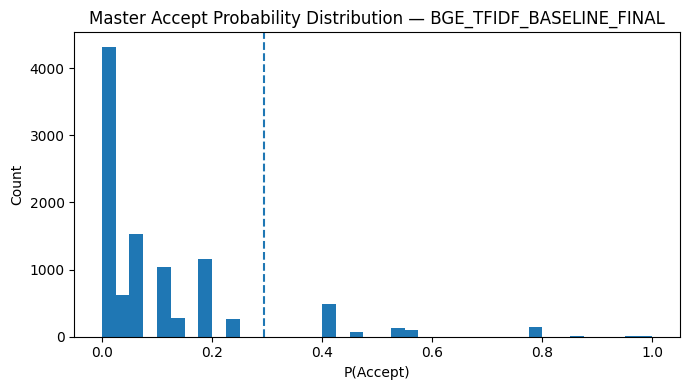

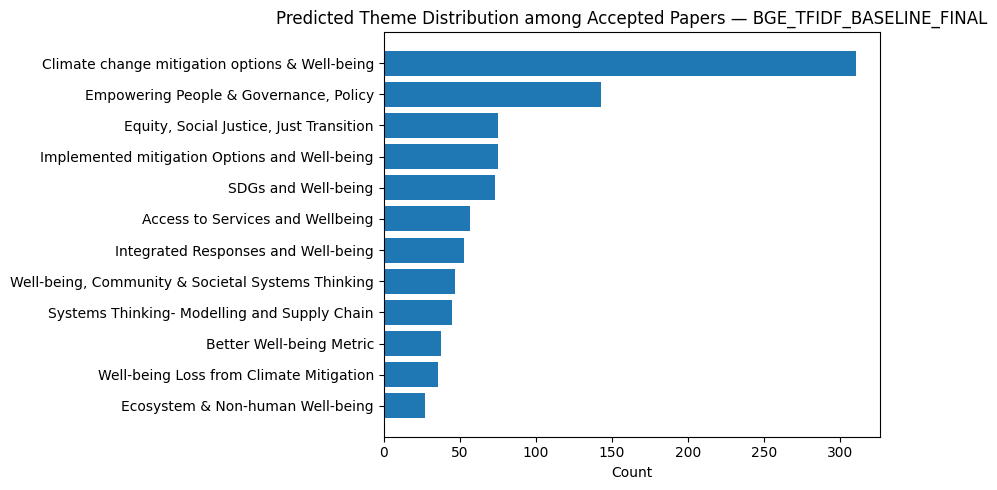

ZIP saved to: /kaggle/working/bge_tfidf_specter_ablation_outputs.zip


In [11]:
# ============================================================
# 9. Theme-wise result tables, diagnostics, and summary export
# ============================================================

final_stage1_metrics = final_result["stage1"]["metrics"]
final_stage2_metrics = final_result["stage2"]["metrics"] if final_result["stage2"] is not None else {}

theme_distribution = (
    out.loc[out["pred_decision"].eq("Accept"), "pred_theme"]
    .value_counts()
    .rename_axis("theme")
    .reset_index(name="predicted_count")
)
theme_distribution["share_of_accepted"] = theme_distribution["predicted_count"] / max(1, int(out["pred_decision"].eq("Accept").sum()))
theme_distribution.to_csv(OUTPUT_DIR / f"{final_prefix}_master_theme_distribution.csv", index=False)

if final_result["stage2"] is not None:
    final_theme_report = final_result["stage2"]["theme_report"].copy()
    final_theme_report.to_csv(OUTPUT_DIR / f"{final_prefix}_theme_validation_report.csv", index=False)
else:
    final_theme_report = pd.DataFrame()

summary = {
    "final_experiment": FINAL_EXPERIMENT_NAME,
    "excluded_models": ["ClimateBERT", "DeBERTa"],
    "baseline_final_policy": "BGE + TF-IDF kept as default final model; SPECTER tested through ablation.",
    "n_training_rows": int(len(train_df)),
    "n_master_rows": int(len(master_df)),
    "n_accept_train": int(y.sum()),
    "train_accept_rate": float(train_accept_rate),
    "n_themes": int(N_THEMES),
    "final_stage1_oof_metrics": final_stage1_metrics,
    "final_stage1_threshold_used": float(final_threshold_used),
    "final_master_accept_count": int(master_accept_final.sum()),
    "final_master_accept_rate": float(master_accept_final.mean()),
    "final_stage2_oof_metrics_accepted_only": final_stage2_metrics,
    "final_stage2_best_prior_alpha": float(stage2_best_alpha),
    "theme_distribution_master_predicted_accepted_only": theme_distribution.set_index("theme")["predicted_count"].to_dict(),
    "ablation_table_file": str(ablation_csv),
    "final_master_file": str(output_xlsx),
}

with open(OUTPUT_DIR / "run_summary.json", "w") as f:
    json.dump(to_py(summary), f, indent=2)

print(json.dumps(to_py(summary), indent=2))

print("\nTheme distribution among predicted accepted master papers:")
display(theme_distribution)

if not final_theme_report.empty:
    print("\nTheme-wise validation report for final experiment:")
    display(final_theme_report)

# Plots
plt.figure(figsize=(7, 4))
plt.hist(master_p_full, bins=40)
plt.axvline(final_threshold_used, linestyle="--")
plt.title(f"Master Accept Probability Distribution — {FINAL_EXPERIMENT_NAME}")
plt.xlabel("P(Accept)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{final_prefix}_master_accept_probability_histogram.png", dpi=200)
plt.show()

if len(theme_distribution) > 0:
    plt.figure(figsize=(9, 5))
    tmp = theme_distribution.sort_values("predicted_count")
    plt.barh(tmp["theme"], tmp["predicted_count"])
    plt.title(f"Predicted Theme Distribution among Accepted Papers — {FINAL_EXPERIMENT_NAME}")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{final_prefix}_master_theme_distribution.png", dpi=200)
    plt.show()

# Zip all outputs
zip_path = OUTPUT_DIR.parent / "bge_tfidf_specter_ablation_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUTPUT_DIR.rglob("*"):
        if p.is_file():
            z.write(p, arcname=str(p.relative_to(OUTPUT_DIR)))

print("ZIP saved to:", zip_path)


In [12]:
# ============================================================
# 10. Auto-generate a short methodology comparison note
# ============================================================

def safe_fmt(x, nd=4):
    try:
        if pd.isna(x):
            return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

completed = ablation_df[ablation_df["status"].eq("completed")].copy()
baseline_row = completed[completed["experiment"].eq("BGE_TFIDF_BASELINE_FINAL")]
specter_combo_row = completed[completed["experiment"].eq("BGE_SPECTER_TFIDF")]

note_lines = []
note_lines.append("# Methodology comparison note")
note_lines.append("")
note_lines.append("## Final model policy")
note_lines.append("")
note_lines.append(f"The default final model is **{FINAL_EXPERIMENT_NAME}**.")
note_lines.append("BGE + TF-IDF is kept as the baseline/final model, while SPECTER is evaluated as an ablation feature.")
note_lines.append("")
note_lines.append("## Key ablation table")
note_lines.append("")
table_cols = [c for c in [
    "experiment", "stage1_AP", "stage1_macro_f1", "stage1_accept_f1",
    "stage2_theme_macro_f1", "stage2_theme_weighted_f1",
    "master_accept_rate", "master_accept_count", "selection_score"
] if c in completed.columns]
small_table = completed[table_cols].copy()
# Avoid optional tabulate dependency; CSV-style text is safer in all Kaggle environments.
note_lines.append(small_table.to_csv(index=False))
note_lines.append("")

if len(baseline_row):
    r = baseline_row.iloc[0]
    note_lines.append("## BGE + TF-IDF baseline/final result")
    note_lines.append("")
    note_lines.append(f"- Stage 1 AP: **{safe_fmt(r.get('stage1_AP'))}**")
    note_lines.append(f"- Stage 1 macro-F1: **{safe_fmt(r.get('stage1_macro_f1'))}**")
    note_lines.append(f"- Accept F1: **{safe_fmt(r.get('stage1_accept_f1'))}**")
    note_lines.append(f"- Theme macro-F1: **{safe_fmt(r.get('stage2_theme_macro_f1'))}**")
    note_lines.append(f"- Master accept rate: **{safe_fmt(r.get('master_accept_rate'))}**")
    note_lines.append("")

if len(specter_combo_row):
    r = specter_combo_row.iloc[0]
    note_lines.append("## BGE + SPECTER + TF-IDF ablation result")
    note_lines.append("")
    note_lines.append(f"- Stage 1 AP: **{safe_fmt(r.get('stage1_AP'))}**")
    note_lines.append(f"- Stage 1 macro-F1: **{safe_fmt(r.get('stage1_macro_f1'))}**")
    note_lines.append(f"- Accept F1: **{safe_fmt(r.get('stage1_accept_f1'))}**")
    note_lines.append(f"- Theme macro-F1: **{safe_fmt(r.get('stage2_theme_macro_f1'))}**")
    note_lines.append(f"- Master accept rate: **{safe_fmt(r.get('master_accept_rate'))}**")
    note_lines.append("")

note_lines.append("## Recommended interpretation")
note_lines.append("")
note_lines.append(
    "Use **BGE + TF-IDF** as the report baseline/final model unless the SPECTER-augmented experiment "
    "improves the accepted-only theme macro-F1 without causing an inflated master accept rate. "
    "Because the task requires both Accept/Reject screening and theme annotation, theme macro-F1 and "
    "theme coverage should be treated as decisive metrics, not only binary macro-F1."
)

note_path = OUTPUT_DIR / "methodology_comparison_note.md"
note_path.write_text("\n".join(note_lines), encoding="utf-8")
print("Saved:", note_path)
print("\n".join(note_lines[:40]))


Saved: /kaggle/working/bge_tfidf_specter_ablation_outputs/methodology_comparison_note.md
# Methodology comparison note

## Final model policy

The default final model is **BGE_TFIDF_BASELINE_FINAL**.
BGE + TF-IDF is kept as the baseline/final model, while SPECTER is evaluated as an ablation feature.

## Key ablation table

experiment,stage1_AP,stage1_macro_f1,stage1_accept_f1,stage2_theme_macro_f1,stage2_theme_weighted_f1,master_accept_rate,master_accept_count,selection_score
SPECTER_TFIDF,0.4269692375167242,0.7085980264127533,0.501010101010101,0.2676504050932799,0.36535313494348026,0.1480935534591195,1507,0.3865788297186115
BGE_SPECTER_TFIDF,0.41799660498139485,0.6959648338858349,0.4648910411622276,0.2831499751962495,0.43670263892133016,0.12175707547169812,1239,0.3854042784063911
TFIDF_ONLY,0.3892305389370323,0.6843522749211661,0.44390243902439025,0.2863741950288983,0.4450188530730669,0.10269261006289308,1045,0.3755153255944824
BGE_TFIDF_BASELINE_FINAL,0.4067022866875903,0.69732577251

## How to use the output files

After running the notebook, check these files first:

1. `ablation_results.csv` / `ablation_results.xlsx`  
   Main numerical comparison table across TF-IDF, BGE, SPECTER, BGE+TF-IDF, SPECTER+TF-IDF, and BGE+SPECTER+TF-IDF.

2. `bge_tfidf_baseline_final_master_annotated.xlsx`  
   Final master annotation file if the default final model remains BGE + TF-IDF.

3. `bge_tfidf_baseline_final_theme_validation_report.csv`  
   Theme-wise precision, recall, F1, and support for the final model.

4. `bge_tfidf_baseline_final_master_theme_distribution.csv`  
   Theme distribution among predicted accepted master papers.

5. `bge_tfidf_baseline_final_top_human_review_candidates.csv`  
   The most important rows to manually check.

6. `methodology_comparison_note.md`  
   A short strategy-wise and numerical summary that can be adapted into your dissertation/report.

### Decision rule

Keep **BGE + TF-IDF** as the final model unless `BGE_SPECTER_TFIDF` clearly improves:

- Stage 1 AP / PR-AUC,
- Accept-class F1,
- accepted-only theme macro-F1,
- and keeps the master accept rate close to the labelled training accept rate.

If SPECTER improves only the binary score but harms theme macro-F1, do **not** use it as the final annotation model.
